
--- Manual Dimensionality Reduction Explanation ---
Axis X (Digital_Habits_Index) = 50% Daily Screen Time + 50% Social Media Time
Axis Y (Mental_Strain_Index)  = 50% Stress Level + 50% Anxiety Level
Additional Features Included  = All One-Hot Encoded Social Media Platforms

Total variance explained by 2 components: 0.48
Total variance explained by 3 components: 0.61

--- Top 5 features influencing PCA (2 Components) ---
PCA1:
stress_level_norm             0.328721
anxiety_level_norm            0.312361
mood_level_norm               0.297404
sleep_hours_norm              0.297372
physical_activity_min_norm    0.296037
Name: PCA1, dtype: float64

PCA2:
social_media_ratio_norm                            0.480006
platform_WhatsApp                                  0.393346
daily_screen_time_without_social_media_min_norm    0.369641
platform_TikTok                                    0.294527
sleep_hours_norm                                   0.257793
Name: PCA2, dtype: float64

--- Top 5 fe

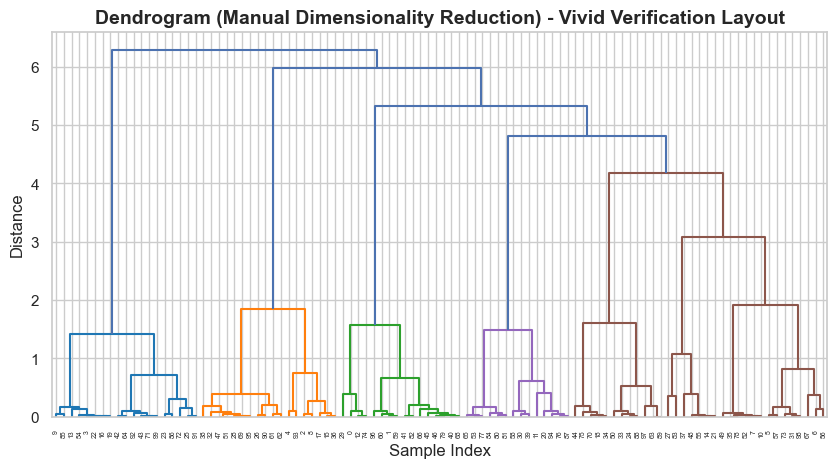

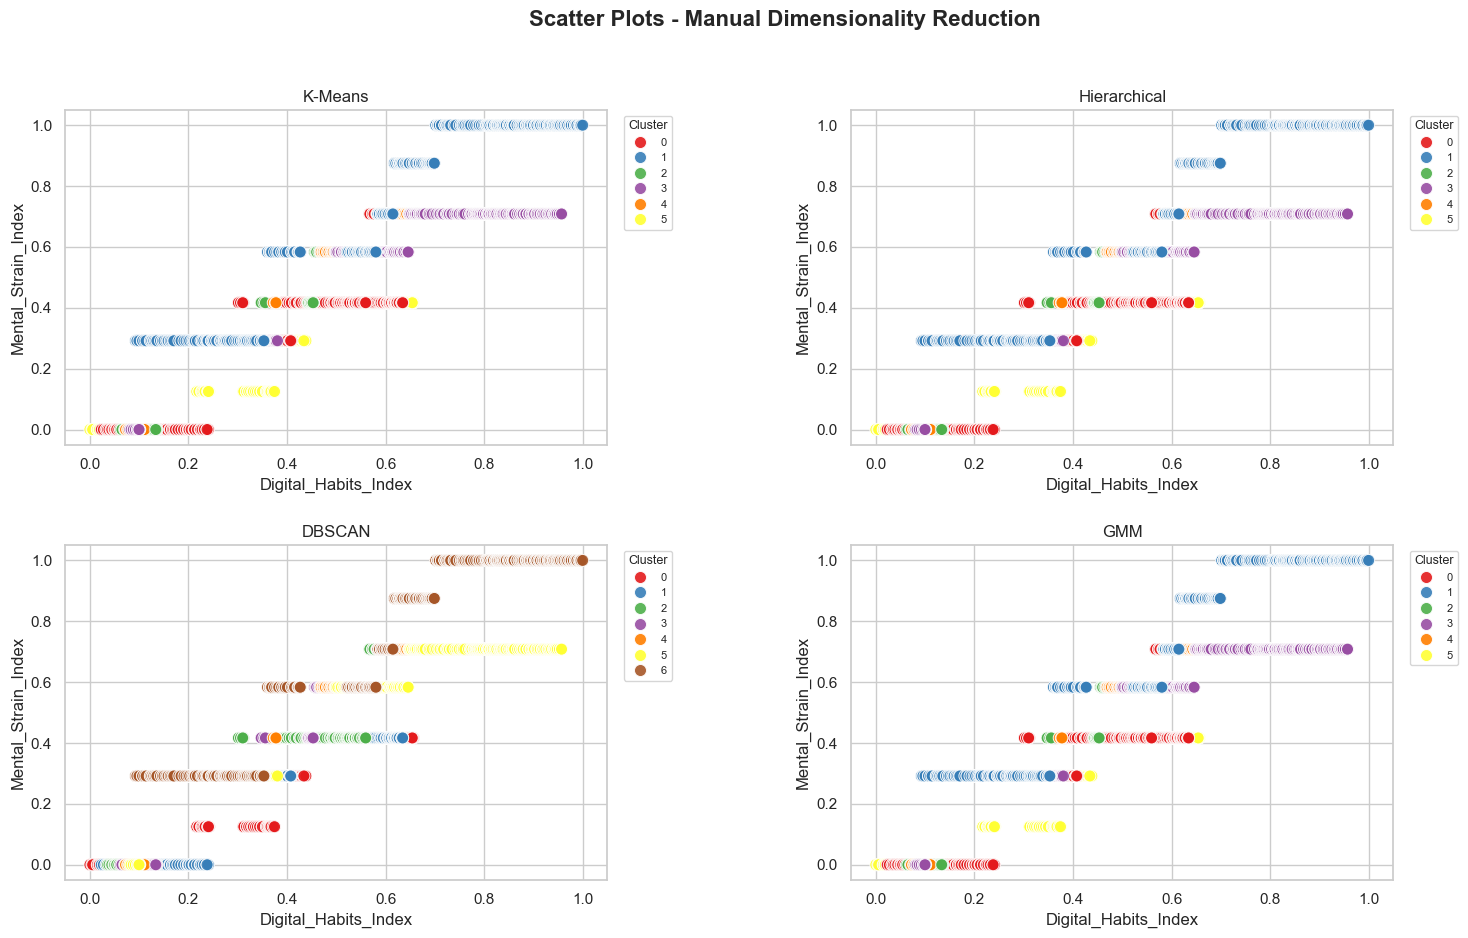

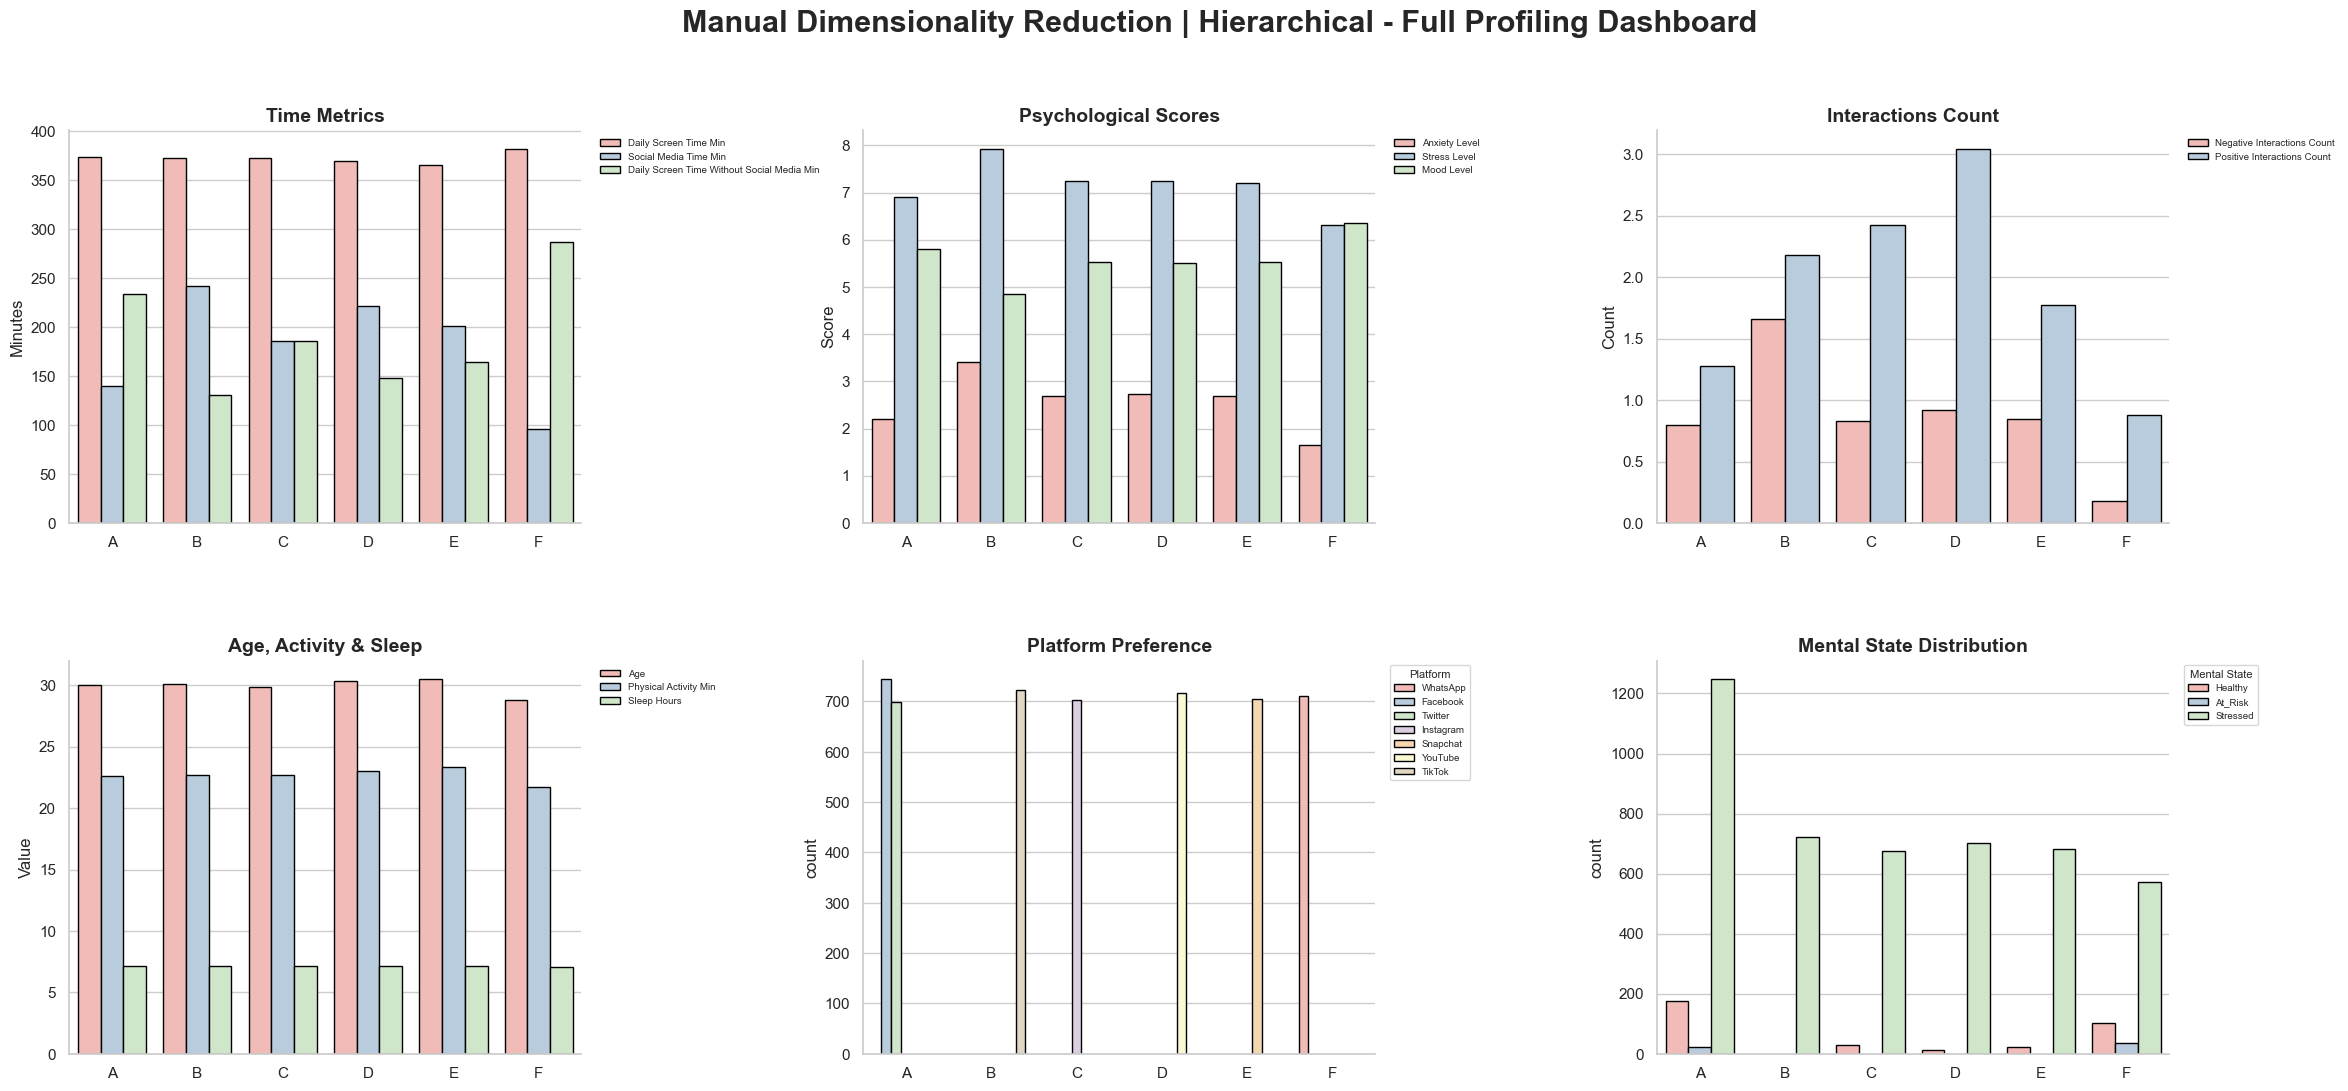

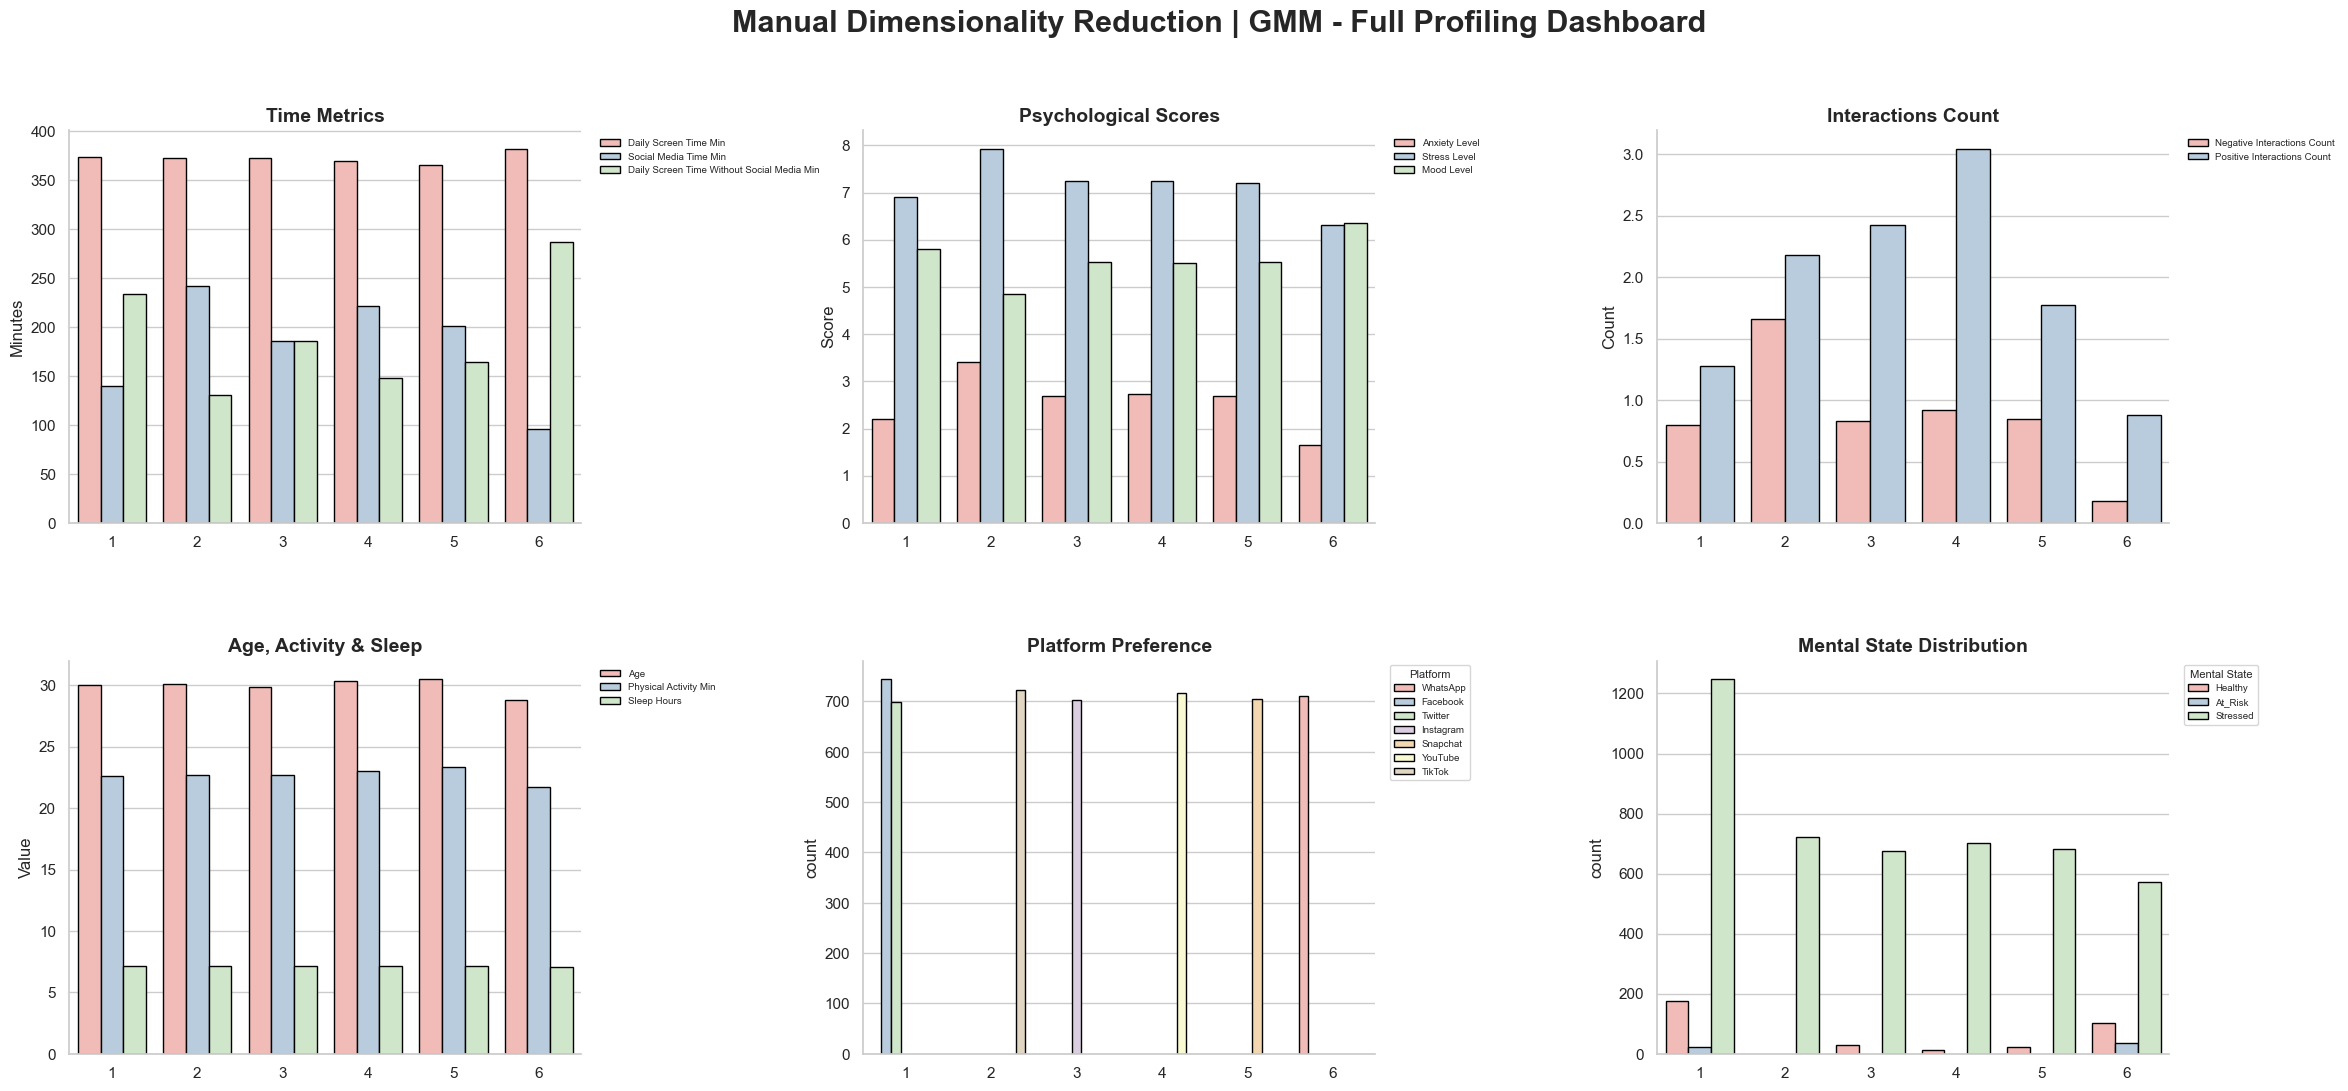


EXECUTING PIPELINE: PCA (2 Components) (3 Clusters)


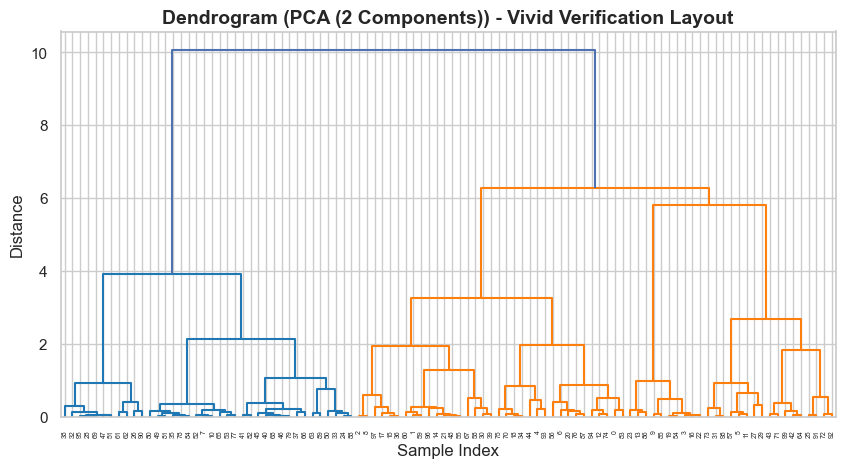

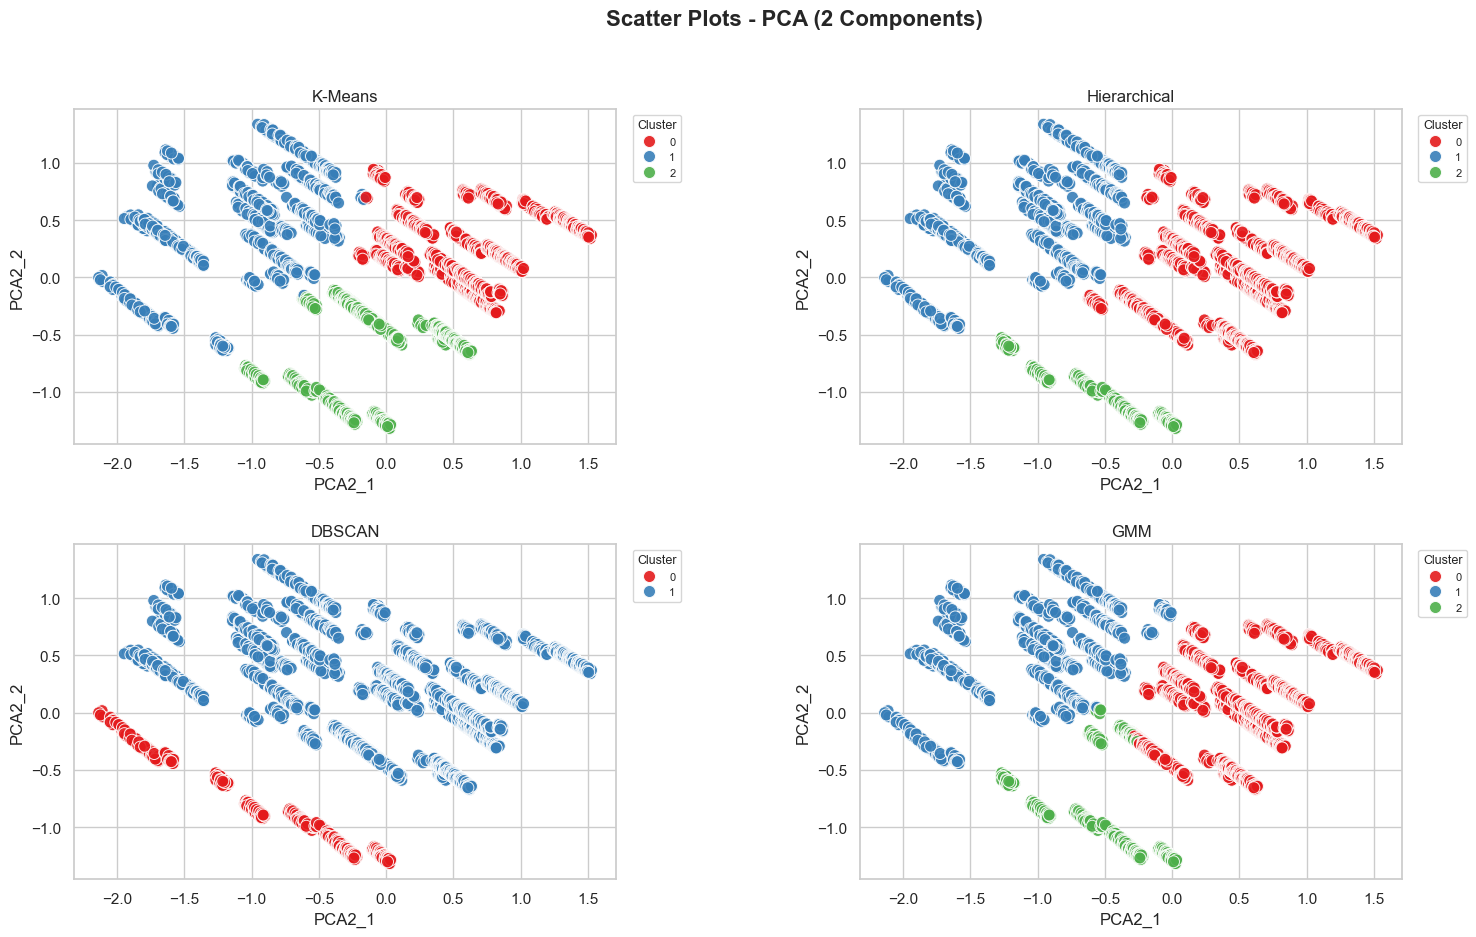

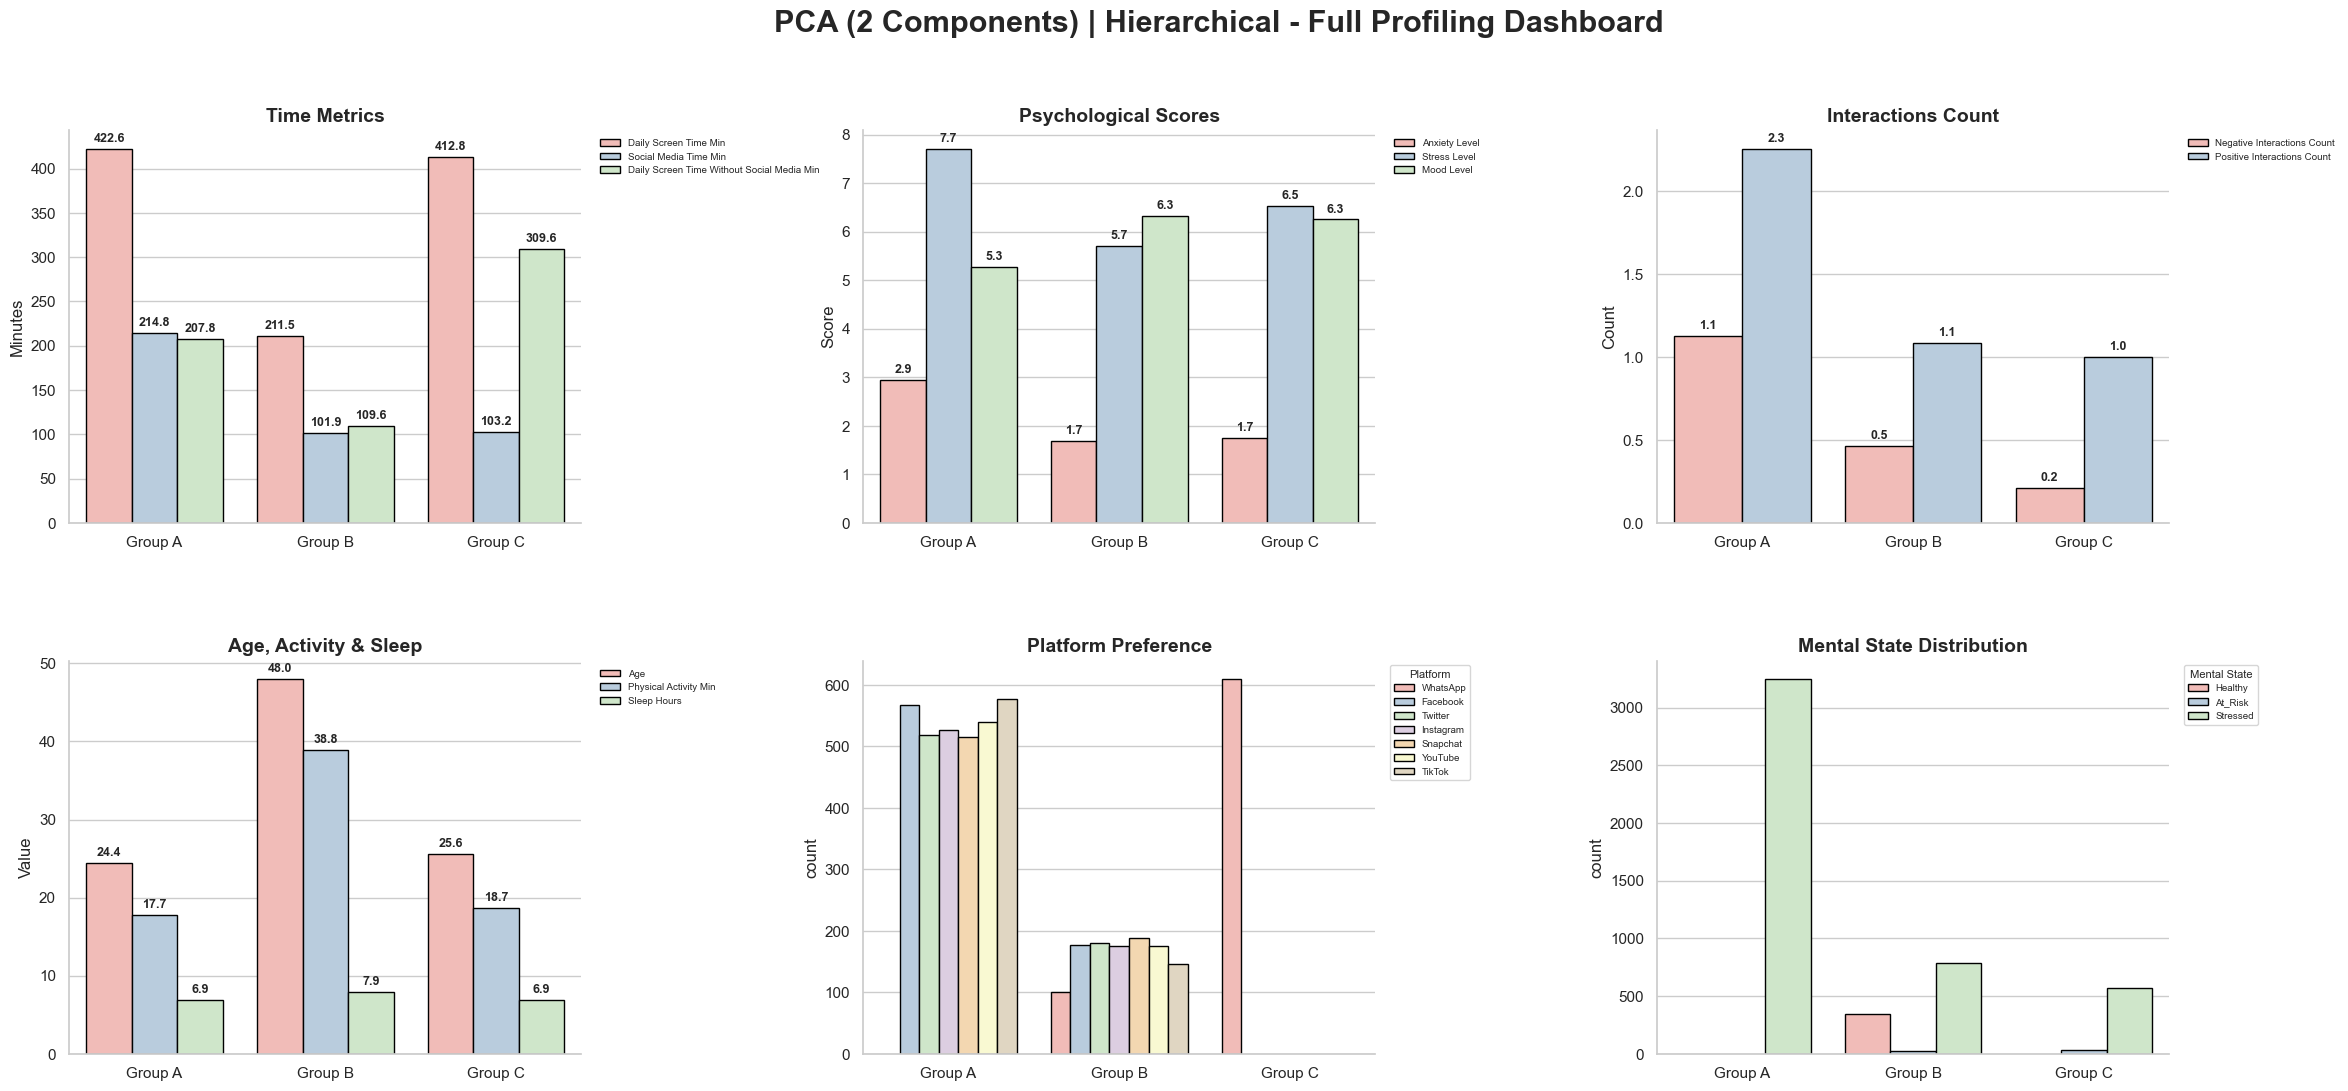

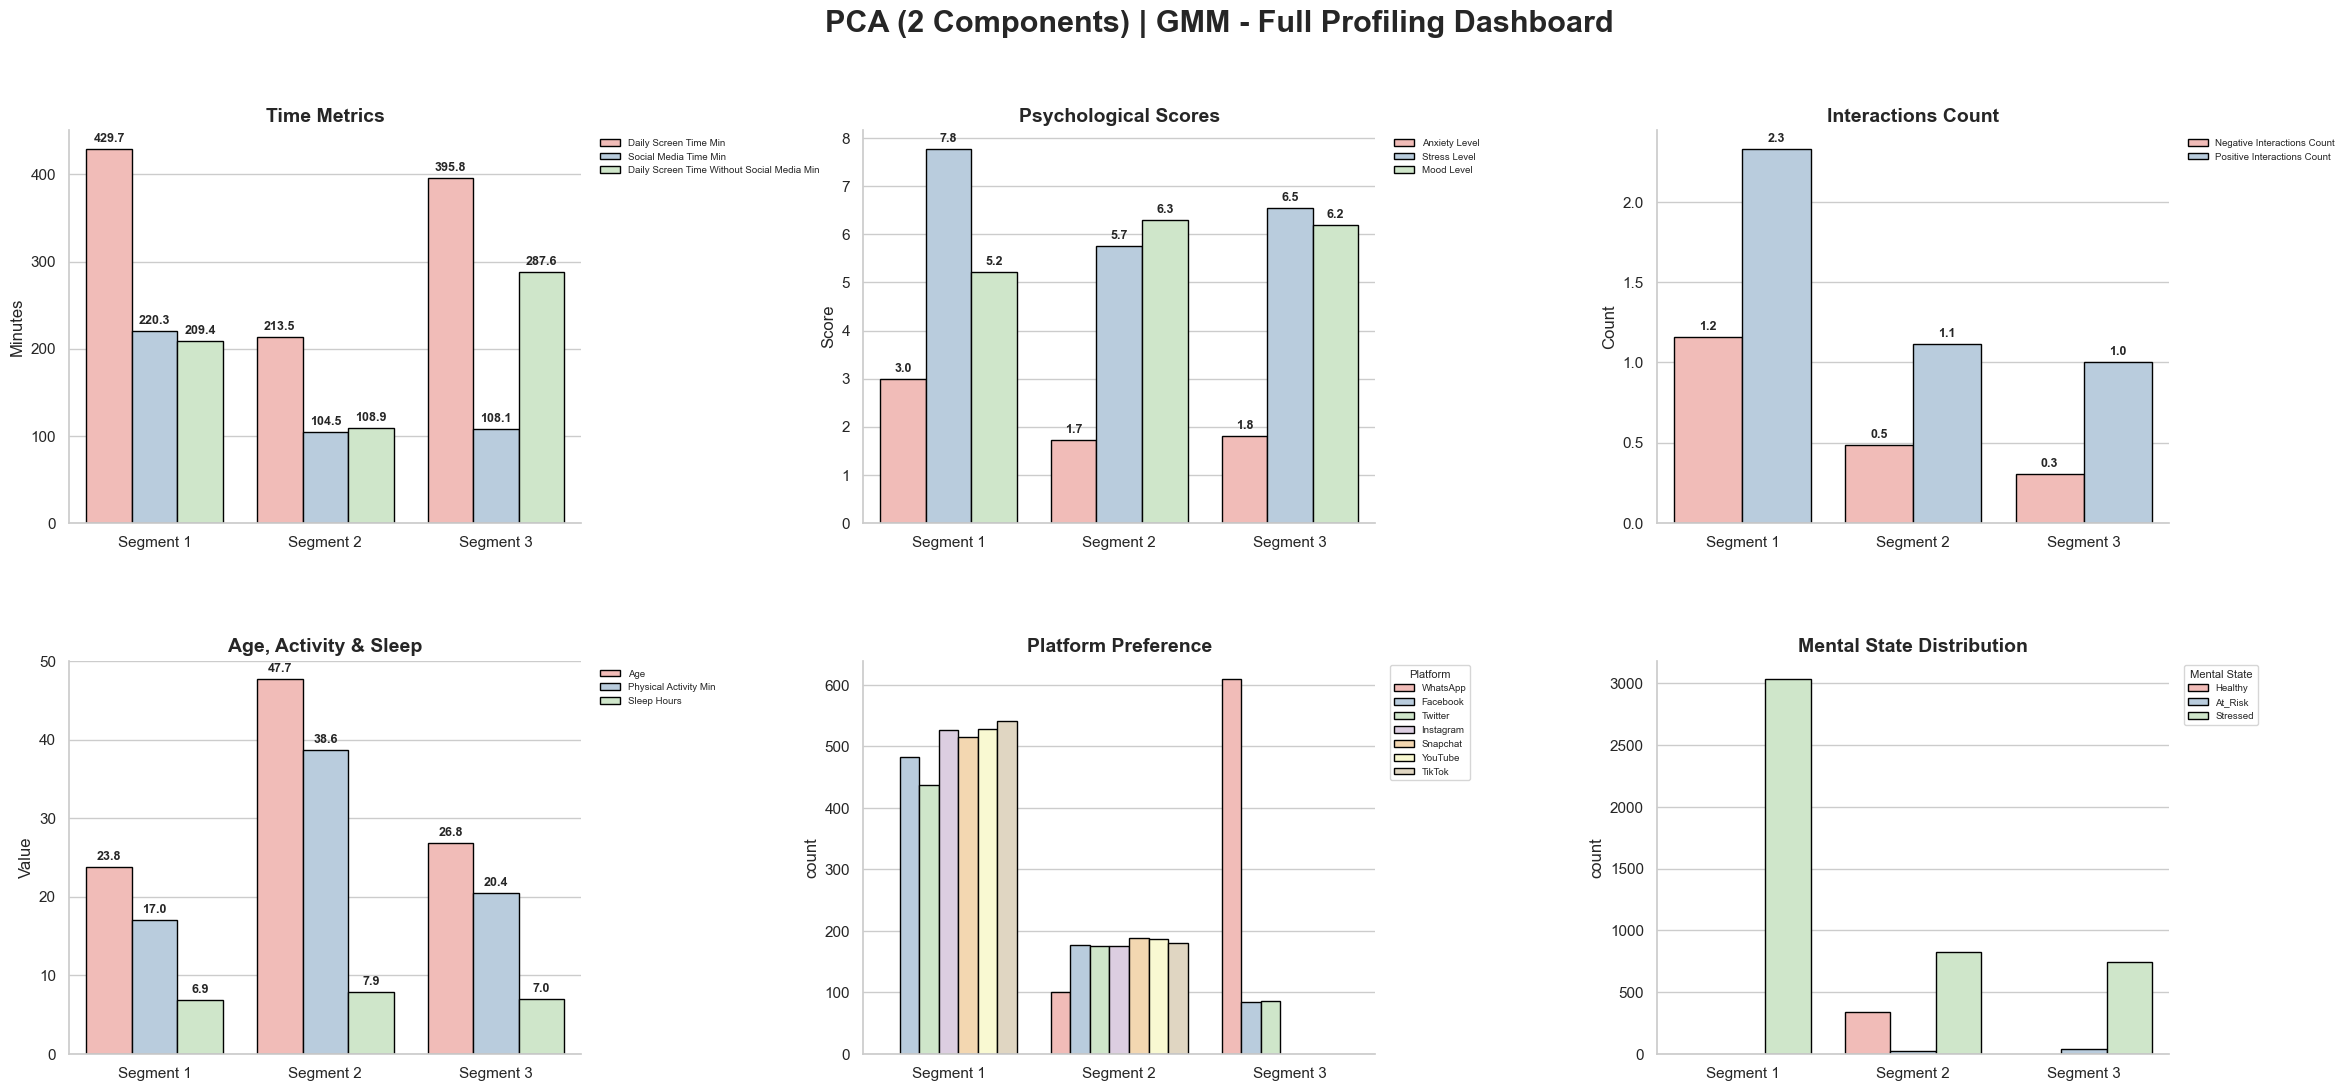


EXECUTING PIPELINE: PCA (3 Components) (3 Clusters)


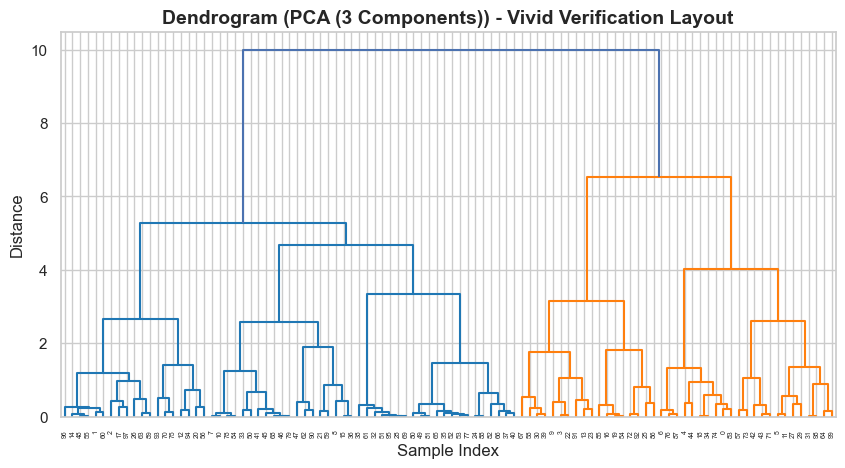

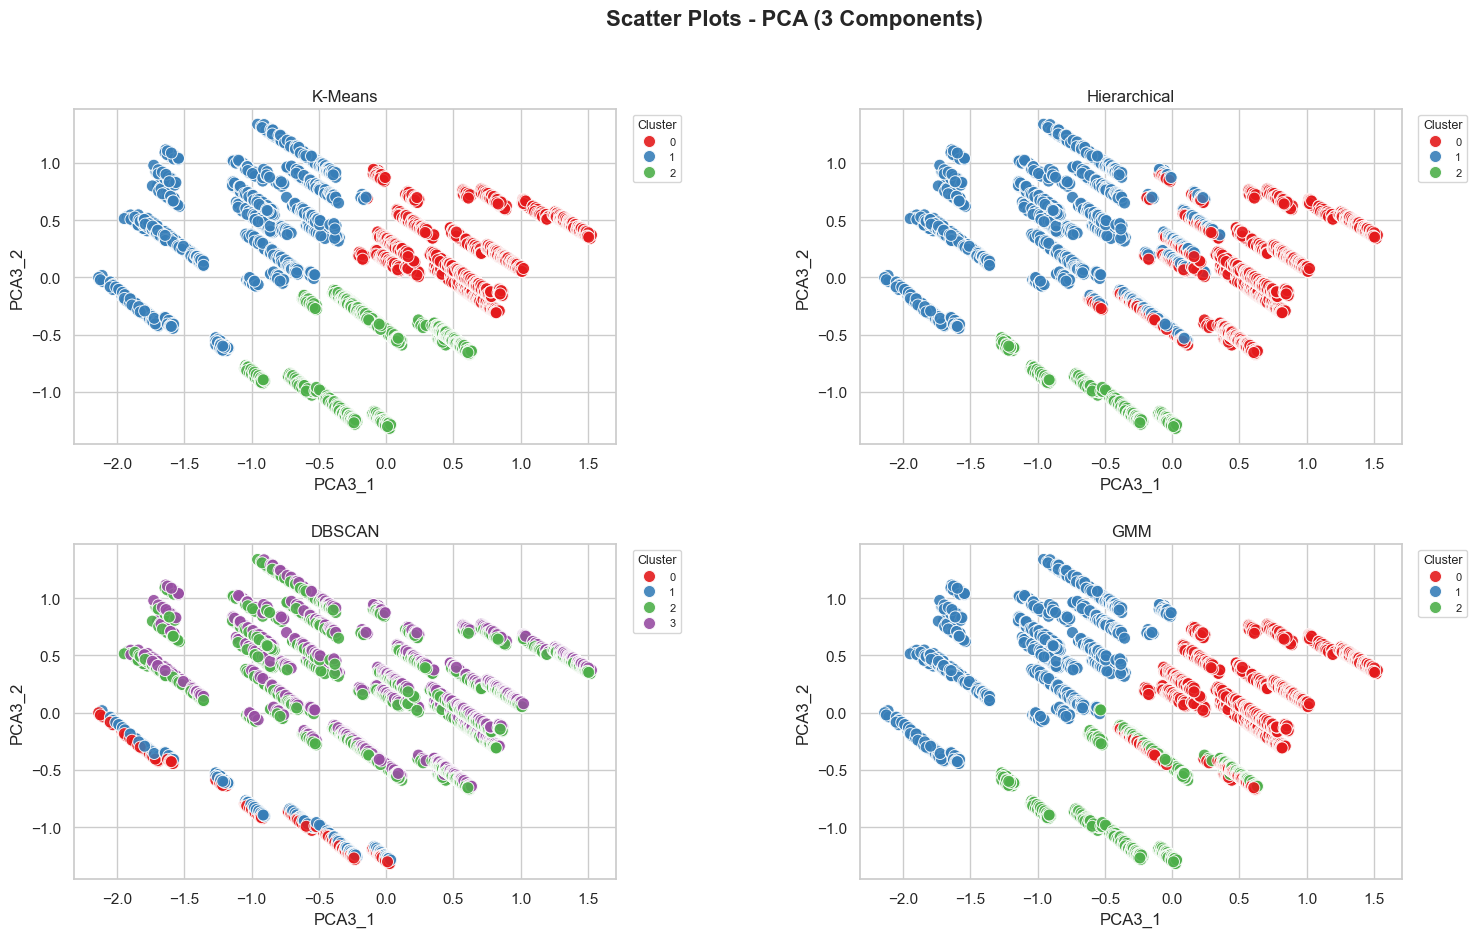

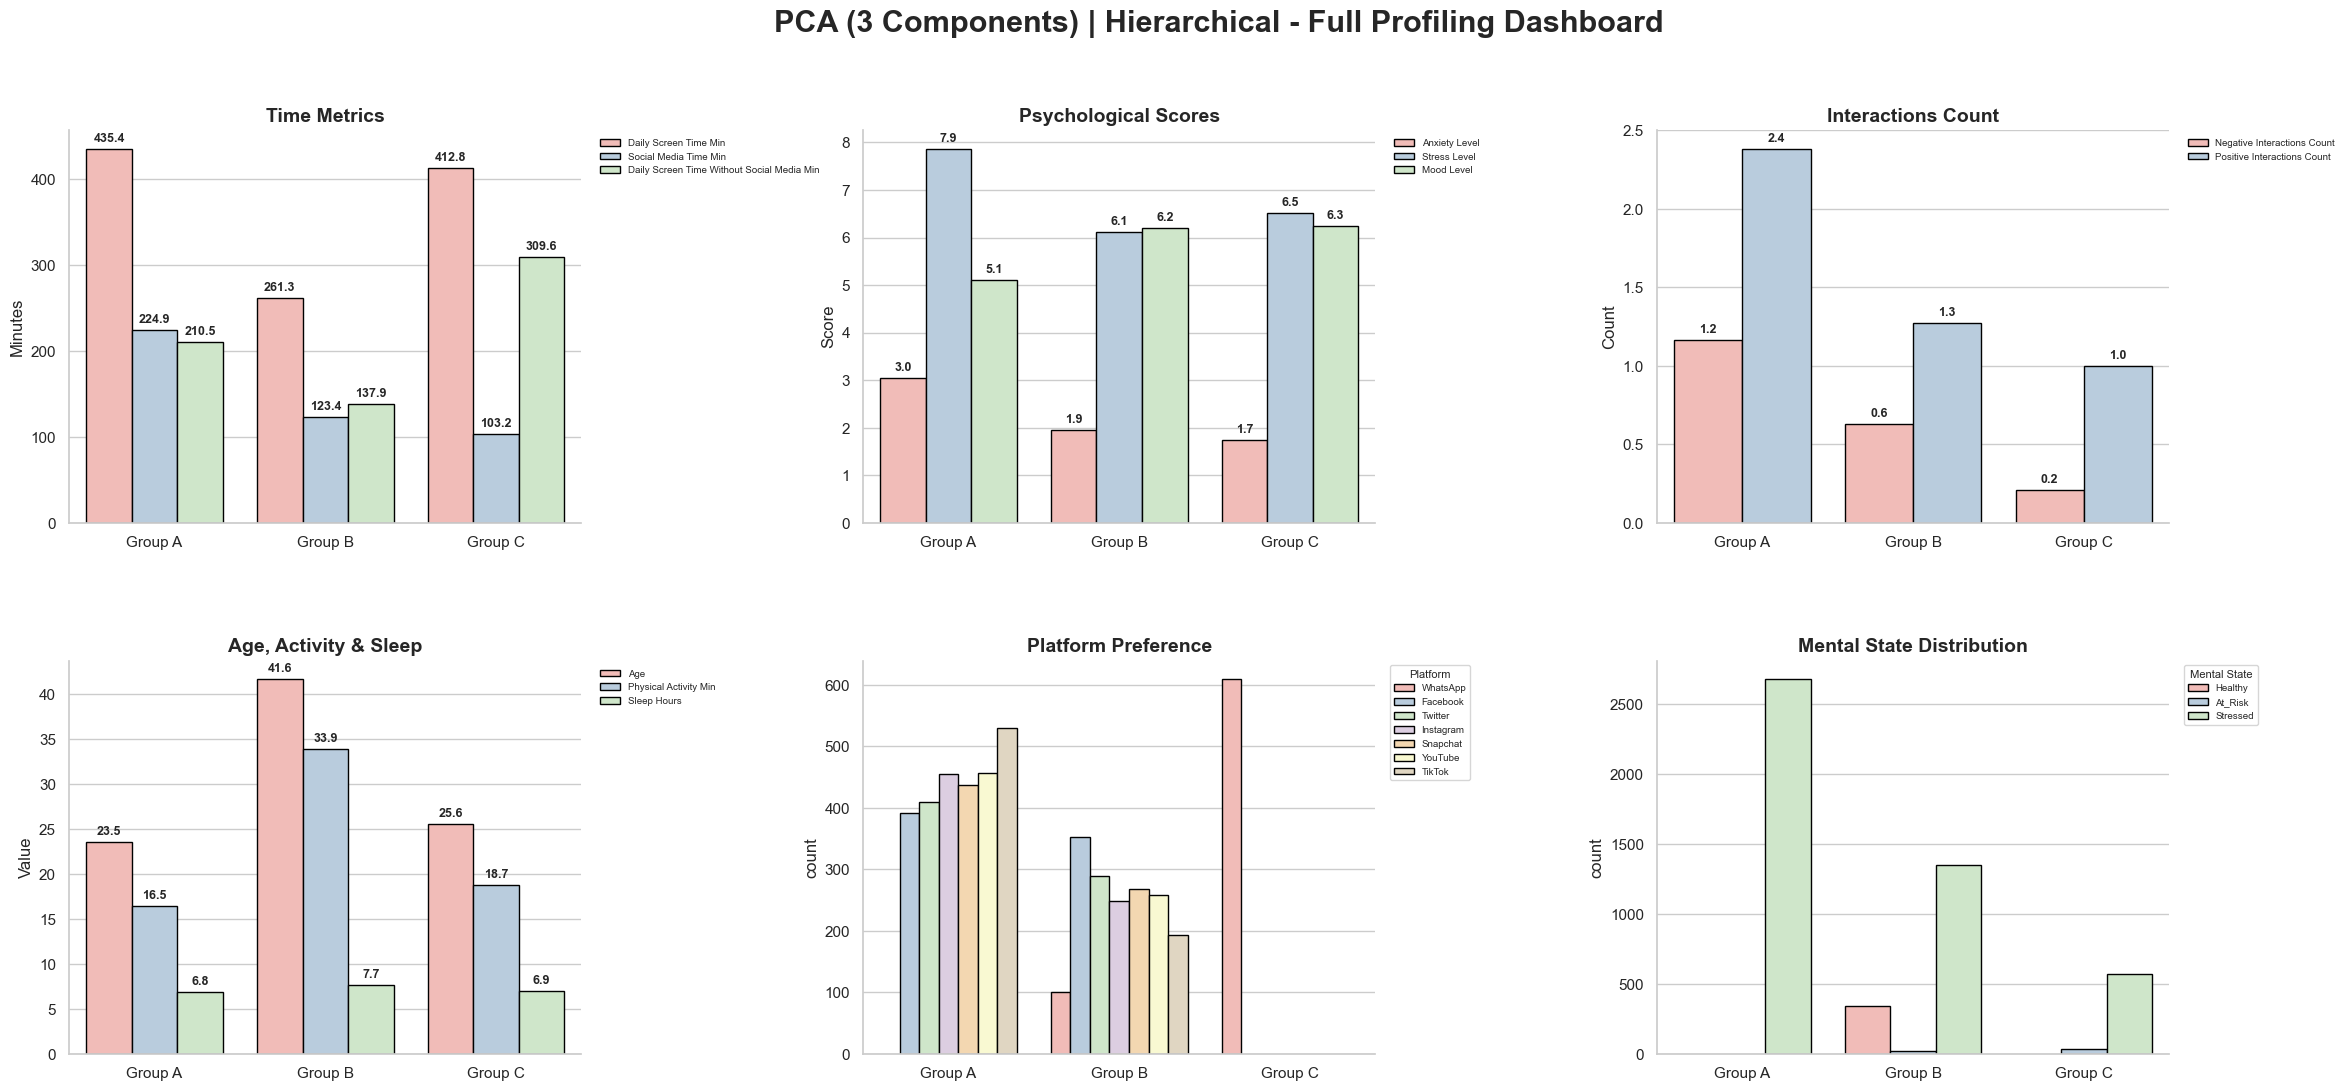

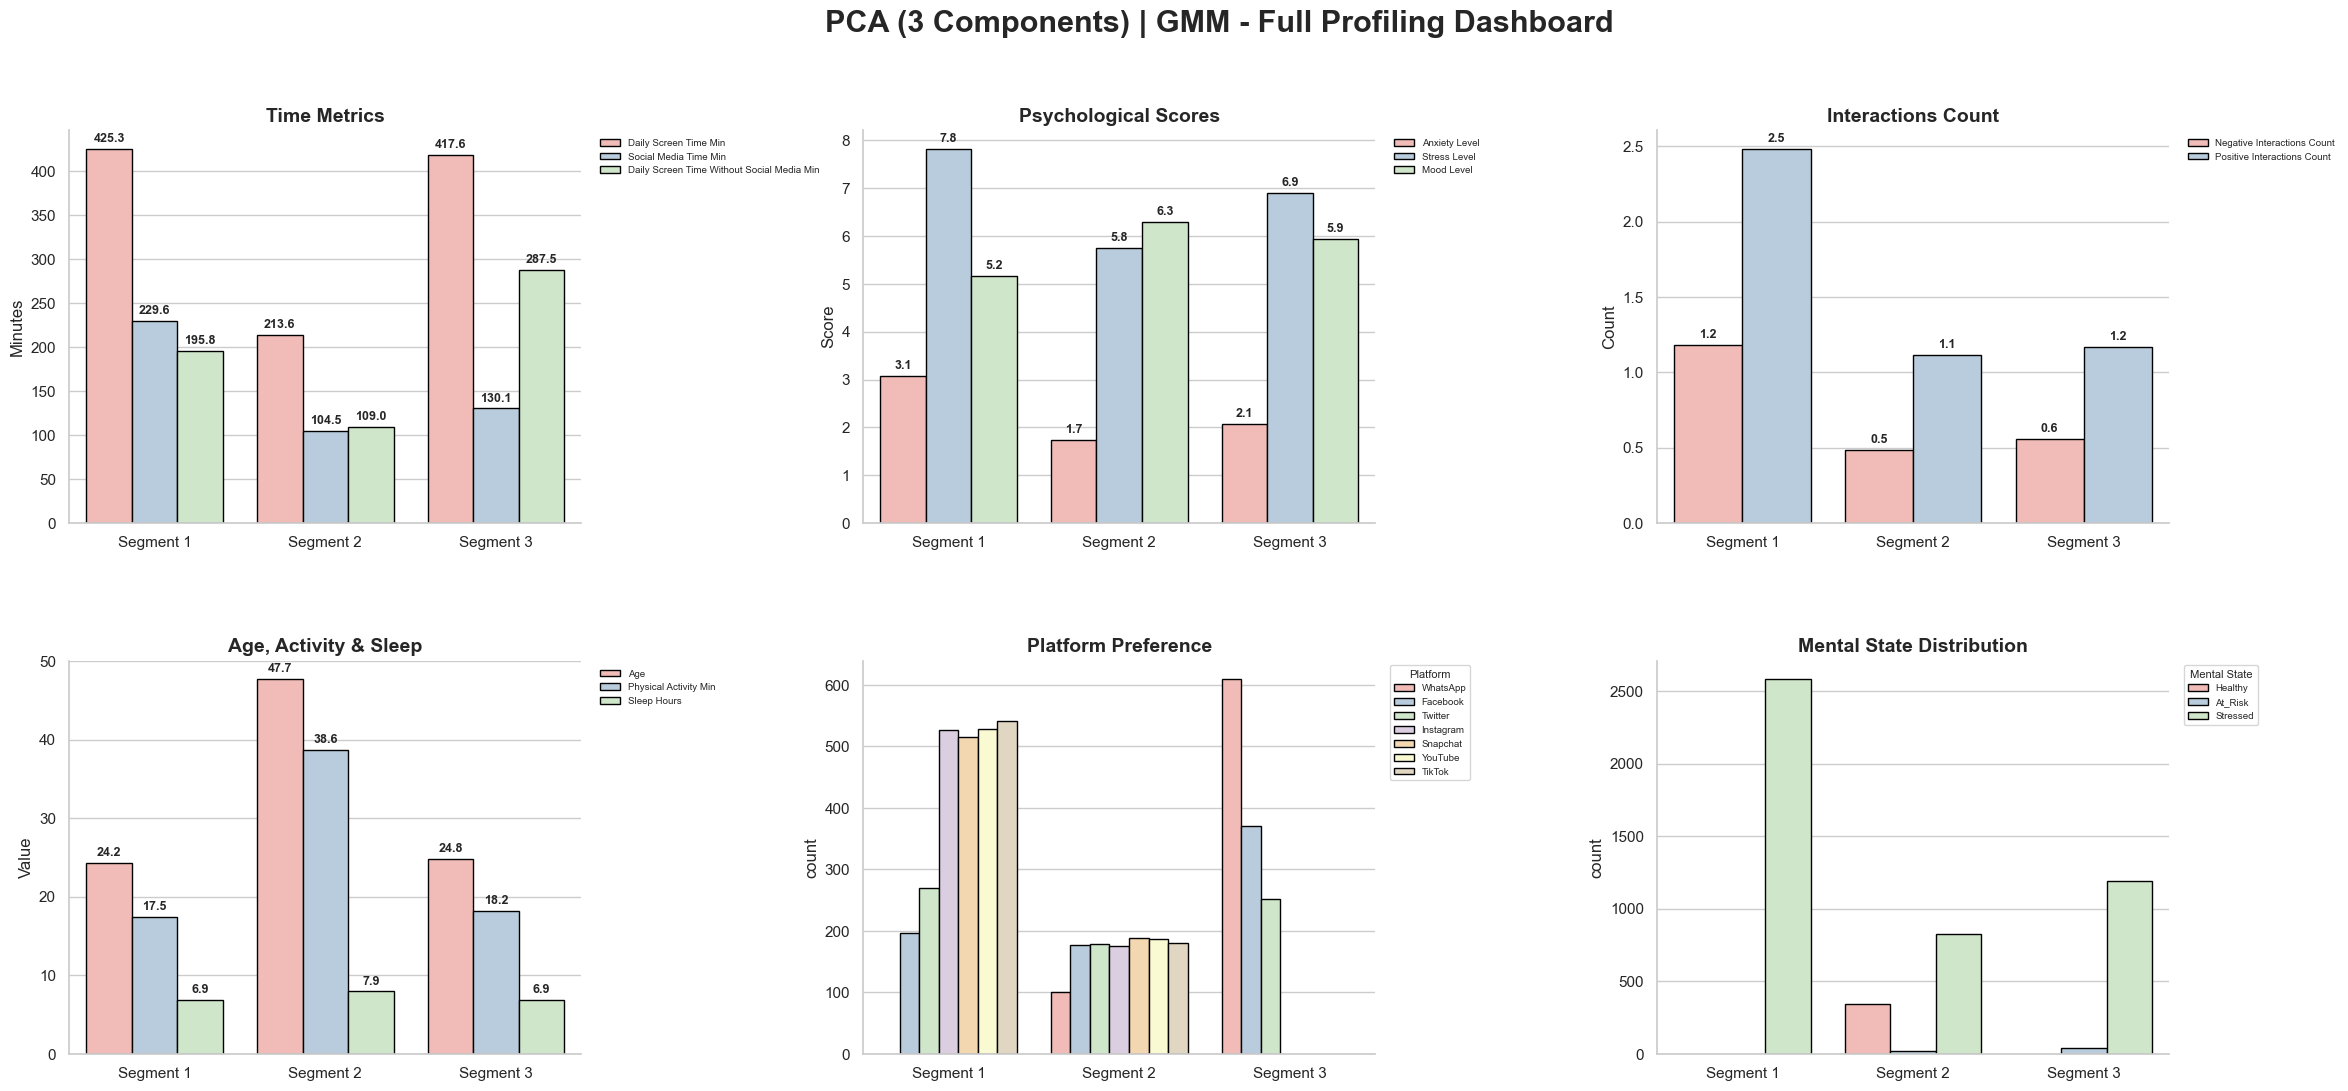

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

# Standard vivid colors for the Dendrogram to separate it from the pastel dashboards
set_link_color_palette(['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2'])

# ==========================================
# 1. NORMALIZE
# ==========================================
df = pd.read_csv("Data.csv")
df_normalized = df.copy()

numerical_cols = [
    'age', 'daily_screen_time_min', 'social_media_time_min',
    'daily_screen_time_without_social_media_min', 'social_media_ratio',
    'negative_interactions_count', 'positive_interactions_count',
    'sleep_hours', 'physical_activity_min', 'activity_to_screen_ratio',
    'anxiety_level', 'stress_level', 'mood_level'
]

scaler = MinMaxScaler()
for col in numerical_cols:
    df_normalized[col + '_norm'] = scaler.fit_transform(df_normalized[[col]])


# ==========================================
# 2. ENCODE
# ==========================================
df_encoded = df_normalized.copy()
mental_state_mapping = {'Healthy': 0, 'Stressed': 1, 'At_Risk': 2}
df_encoded['mental_state_encoded'] = df_encoded['mental_state'].map(mental_state_mapping)
df_encoded = pd.get_dummies(df_encoded, columns=['platform', 'gender'], drop_first=True)


# ==========================================
# 3. MANUAL DIMENSIONALITY REDUCTION (CUSTOM INDEXES + PLATFORMS)
# ==========================================
df_encoded['Digital_Habits_Index'] = (df_encoded['daily_screen_time_min_norm'] + df_encoded['social_media_time_min_norm']) / 2
df_encoded['Mental_Strain_Index'] = (df_encoded['stress_level_norm'] + df_encoded['anxiety_level_norm']) / 2

one_hot_platforms = [col for col in df_encoded.columns if col.startswith('platform_')]
manual_features = ['Digital_Habits_Index', 'Mental_Strain_Index'] + one_hot_platforms

print("\n" + "="*50)
print("--- Manual Dimensionality Reduction Explanation ---")
print("Axis X (Digital_Habits_Index) = 50% Daily Screen Time + 50% Social Media Time")
print("Axis Y (Mental_Strain_Index)  = 50% Stress Level + 50% Anxiety Level")
print("Additional Features Included  = All One-Hot Encoded Social Media Platforms")
print("="*50 + "\n")


# ==========================================
# 4. DIMENSIONALITY REDUCTION (PCA 2 & 3)
# ==========================================
pca_base_features = [col + '_norm' for col in numerical_cols] + ['mental_state_encoded']
one_hot_features = [col for col in df_encoded.columns if col.startswith('platform_') or col.startswith('gender_')]
pca_base_features.extend(one_hot_features)

# PCA with 2 components
pca2 = PCA(n_components=2)
pca2_results = pca2.fit_transform(df_encoded[pca_base_features])
df_encoded['PCA2_1'] = pca2_results[:, 0]
df_encoded['PCA2_2'] = pca2_results[:, 1]
pca2_features = ['PCA2_1', 'PCA2_2']
print(f"Total variance explained by 2 components: {pca2.explained_variance_ratio_.sum():.2f}")

# PCA with 3 components
pca3 = PCA(n_components=3)
pca3_results = pca3.fit_transform(df_encoded[pca_base_features])
df_encoded['PCA3_1'] = pca3_results[:, 0]
df_encoded['PCA3_2'] = pca3_results[:, 1]
df_encoded['PCA3_3'] = pca3_results[:, 2]
pca3_features = ['PCA3_1', 'PCA3_2', 'PCA3_3']
print(f"Total variance explained by 3 components: {pca3.explained_variance_ratio_.sum():.2f}")

# --- Printing the Top Features influencing the 2-Component PCA ---
components_df_2 = pd.DataFrame(pca2.components_, columns=pca_base_features, index=['PCA1', 'PCA2'])
print("\n" + "="*50)
print("--- Top 5 features influencing PCA (2 Components) ---")
print("PCA1:")
print(components_df_2.loc['PCA1'].abs().sort_values(ascending=False).head(5))
print("\nPCA2:")
print(components_df_2.loc['PCA2'].abs().sort_values(ascending=False).head(5))

# --- Printing the Top Features influencing the 3-Component PCA ---
components_df_3 = pd.DataFrame(pca3.components_, columns=pca_base_features, index=['PCA1', 'PCA2', 'PCA3'])
print("\n--- Top 5 features influencing PCA (3 Components) ---")
print("PCA1:")
print(components_df_3.loc['PCA1'].abs().sort_values(ascending=False).head(5))
print("\nPCA2:")
print(components_df_3.loc['PCA2'].abs().sort_values(ascending=False).head(5))
print("\nWhite PCA3:")
print(components_df_3.loc['PCA3'].abs().sort_values(ascending=False).head(5))
print("="*50 + "\n")


# ==========================================
# 5. MASTER FUNCTION FOR CLUSTERING & PROFILING
# ==========================================
def run_clustering_pipeline(run_name, feature_list, x_col, y_col, scatter_palette, dashboard_palette, num_clusters=3, show_labels=True):
    print(f"\n{'='*50}\nEXECUTING PIPELINE: {run_name} ({num_clusters} Clusters)\n{'='*50}")
    
    # --- A. Dendrogram ---
    df_small = df_encoded.sample(n=100, random_state=42)
    Z = linkage(df_small[feature_list], method='ward')
    plt.figure(figsize=(10, 5))
    dendrogram(Z)
    plt.title(f"Dendrogram ({run_name}) - Vivid Verification Layout", fontsize=14, fontweight='bold')
    plt.xlabel("Sample Index")
    plt.ylabel("Distance")
    plt.show()

    # --- B. Execute Algorithms ---
    df_clusters = pd.DataFrame(index=df_encoded.index)
    
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    df_clusters['KMeans_Labels'] = kmeans.fit_predict(df_encoded[feature_list])

    hierarchical = AgglomerativeClustering(n_clusters=num_clusters)
    df_clusters['Hierarchical_Labels'] = hierarchical.fit_predict(df_encoded[feature_list])

    dbscan = DBSCAN(eps=0.5, min_samples=5)
    df_clusters['DBSCAN_Labels'] = dbscan.fit_predict(df_encoded[feature_list])

    gmm = GaussianMixture(n_components=num_clusters, random_state=42)
    df_clusters['GMM_Labels'] = gmm.fit_predict(df_encoded[feature_list])

    # Aligning GMM and KMeans labels to match Hierarchical labels dynamically
    cm_gmm = confusion_matrix(df_clusters['Hierarchical_Labels'], df_clusters['GMM_Labels'])
    row_ind_gmm, col_ind_gmm = linear_sum_assignment(-cm_gmm)
    gmm_map = {col_ind_gmm[i]: row_ind_gmm[i] for i in range(len(row_ind_gmm))}
    df_clusters['GMM_Labels'] = df_clusters['GMM_Labels'].map(gmm_map)

    cm_km = confusion_matrix(df_clusters['Hierarchical_Labels'], df_clusters['KMeans_Labels'])
    row_ind_km, col_ind_km = linear_sum_assignment(-cm_km)
    km_map = {col_ind_km[i]: row_ind_km[i] for i in range(len(row_ind_km))}
    df_clusters['KMeans_Labels'] = df_clusters['KMeans_Labels'].map(km_map)

    # --- C. Scatter Plots ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Scatter Plots - {run_name}', fontsize=16, fontweight='bold')
    
    sns.scatterplot(data=df_encoded, x=x_col, y=y_col, hue=df_clusters['KMeans_Labels'], palette=scatter_palette, ax=axes[0, 0], s=75, alpha=0.9)
    axes[0, 0].set_title('K-Means')
    axes[0, 0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cluster', title_fontsize=9)

    sns.scatterplot(data=df_encoded, x=x_col, y=y_col, hue=df_clusters['Hierarchical_Labels'], palette=scatter_palette, ax=axes[0, 1], s=75, alpha=0.9)
    axes[0, 1].set_title('Hierarchical')
    axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cluster', title_fontsize=9)

    sns.scatterplot(data=df_encoded, x=x_col, y=y_col, hue=df_clusters['DBSCAN_Labels'], palette=scatter_palette, ax=axes[1, 0], s=75, alpha=0.9)
    axes[1, 0].set_title('DBSCAN')
    axes[1, 0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cluster', title_fontsize=9)

    sns.scatterplot(data=df_encoded, x=x_col, y=y_col, hue=df_clusters['GMM_Labels'], palette=scatter_palette, ax=axes[1, 1], s=75, alpha=0.9)
    axes[1, 1].set_title('GMM')
    axes[1, 1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cluster', title_fontsize=9)

    plt.subplots_adjust(left=0.05, right=0.88, wspace=0.45, hspace=0.3)
    plt.show()

    # --- D. Profiling Dashboards ---
    df_profile = df.copy()
    
    # Drop prefixes to save space if there are more than 3 clusters
    if num_clusters > 3:
        hierarchical_names = [chr(65+i) for i in range(num_clusters)] # A, B, C, D...
        gmm_names = [str(i+1) for i in range(num_clusters)] # 1, 2, 3, 4...
    else:
        hierarchical_names = [f'Group {chr(65+i)}' for i in range(num_clusters)] # Group A, Group B...
        gmm_names = [f'Segment {i+1}' for i in range(num_clusters)] # Segment 1, Segment 2...
    
    hier_map = {i: hierarchical_names[i] for i in range(num_clusters)}
    gmm_map_names = {i: gmm_names[i] for i in range(num_clusters)}

    df_profile['Hierarchical_Named'] = df_clusters['Hierarchical_Labels'].map(hier_map)
    df_profile['GMM_Named'] = df_clusters['GMM_Labels'].map(gmm_map_names)

    time_features = ['daily_screen_time_min', 'social_media_time_min', 'daily_screen_time_without_social_media_min']
    psycho_features = ['anxiety_level', 'stress_level', 'mood_level']
    interaction_features = ['negative_interactions_count', 'positive_interactions_count']
    health_features = ['age', 'physical_activity_min', 'sleep_hours']

    def plot_dashboard(cluster_col, algo_name, exact_order):
        fig, axes_dash = plt.subplots(2, 3, figsize=(25, 12))
        fig.suptitle(f'{run_name} | {algo_name} - Full Profiling Dashboard', fontsize=22, fontweight='bold')
        
        def add_num_subplot(ax_obj, features, title, ylabel):
            df_melted = df_profile.melt(id_vars=[cluster_col], value_vars=features, var_name='Metric', value_name='Value')
            df_melted['Metric'] = df_melted['Metric'].str.replace('_', ' ').str.title()
            sns.barplot(data=df_melted, x=cluster_col, y='Value', hue='Metric', ax=ax_obj, palette=dashboard_palette, edgecolor='black', errorbar=None, order=exact_order)
            ax_obj.set_title(title, fontsize=14, fontweight='bold')
            ax_obj.set_ylabel(ylabel)
            ax_obj.set_xlabel('')
            ax_obj.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, frameon=True, edgecolor='none')
            
            if show_labels:
                for container in ax_obj.containers:
                    ax_obj.bar_label(container, fmt='%.1f', padding=3, fontsize=9, fontweight='bold')

        add_num_subplot(axes_dash[0, 0], time_features, 'Time Metrics', 'Minutes')
        add_num_subplot(axes_dash[0, 1], psycho_features, 'Psychological Scores', 'Score')
        add_num_subplot(axes_dash[0, 2], interaction_features, 'Interactions Count', 'Count')
        add_num_subplot(axes_dash[1, 0], health_features, 'Age, Activity & Sleep', 'Value')
        
        # Platform Countplot
        sns.countplot(data=df_profile, x=cluster_col, hue='platform', palette=dashboard_palette, edgecolor='black', ax=axes_dash[1, 1], order=exact_order)
        axes_dash[1, 1].set_title('Platform Preference', fontsize=14, fontweight='bold')
        axes_dash[1, 1].set_xlabel('')
        axes_dash[1, 1].legend(title='Platform', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, title_fontsize=8, frameon=True)

        # Mental State Countplot
        sns.countplot(data=df_profile, x=cluster_col, hue='mental_state', palette=dashboard_palette, edgecolor='black', ax=axes_dash[1, 2], order=exact_order)
        axes_dash[1, 2].set_title('Mental State Distribution', fontsize=14, fontweight='bold')
        axes_dash[1, 2].set_xlabel('')
        axes_dash[1, 2].legend(title='Mental State', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, title_fontsize=8, frameon=True)

        sns.despine()
        plt.subplots_adjust(left=0.04, right=0.88, wspace=0.55, hspace=0.35)
        plt.show()

    plot_dashboard('Hierarchical_Named', 'Hierarchical', hierarchical_names)
    plot_dashboard('GMM_Named', 'GMM', gmm_names)


# ==========================================
# 6. RUNNING THE PIPELINES
# ==========================================
sns.set_theme(style="whitegrid")

# Run Manual Features with exactly 6 clusters and data labels hidden
run_clustering_pipeline(run_name="Manual Dimensionality Reduction", 
                        feature_list=manual_features, 
                        x_col='Digital_Habits_Index', 
                        y_col='Mental_Strain_Index',
                        scatter_palette='Set1',
                        dashboard_palette='Pastel1',
                        num_clusters=6,
                        show_labels=False)

# Leave PCA runs firmly at 3 clusters with data labels shown
run_clustering_pipeline(run_name="PCA (2 Components)", 
                        feature_list=pca2_features, 
                        x_col='PCA2_1', 
                        y_col='PCA2_2',
                        scatter_palette='Set1',
                        dashboard_palette='Pastel1',
                        num_clusters=3,
                        show_labels=True)

run_clustering_pipeline(run_name="PCA (3 Components)", 
                        feature_list=pca3_features, 
                        x_col='PCA3_1', 
                        y_col='PCA3_2',
                        scatter_palette='Set1',
                        dashboard_palette='Pastel1',
                        num_clusters=3,
                        show_labels=True)